# EDA

# AI Sports Talent Scout - Exploratory Data Analysis

Objective:
Analyze player performance data to identify patterns affecting talent score, future potential, and auction value.

Key Questions:
1. Which player role dominates the dataset?
2. How are talent scores distributed?
3. Which factors influence auction value?
4. Do younger players show higher future potential?
5. What characteristics define elite players?

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Step 2: Load Dataset

In [2]:
df = pd.read_csv("players.csv")

df.head()

,player_id,age,role,matches,runs,batting_average,strike_rate,fifties,hundreds,wickets,economy,catches,fitness_score,raw_score,talent_score,future_potential,auction_value_cr
0,1,21,Batter,199,5253,42.35,129.77,16,18,2,8.36,14,80,67.5165,31.46,Low,6.18
1,2,20,Bowler,69,1034,22.04,98.06,5,1,156,5.80,22,80,66.4690,29.48,Low,7.69
2,3,23,Wicketkeeper,97,4276,29.66,167.00,26,3,1,7.52,95,91,79.7900,54.73,Medium,8.39
3,4,26,Batter,196,6763,51.09,188.12,34,3,17,7.17,56,88,91.6910,77.28,High,12.93
4,5,24,Batter,21,4866,58.19,188.97,24,4,12,7.11,56,85,89.1245,72.42,High,11.72


## Step 3: Basic Dataset Information

In [3]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

print(df.describe())

(3000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         3000 non-null   int64  
 1   age               3000 non-null   int64  
 2   role              3000 non-null   object 
 3   matches           3000 non-null   int64  
 4   runs              3000 non-null   int64  
 5   batting_average   3000 non-null   float64
 6   strike_rate       3000 non-null   float64
 7   fifties           3000 non-null   int64  
 8   hundreds          3000 non-null   int64  
 9   wickets           3000 non-null   int64  
 10  economy           3000 non-null   float64
 11  catches           3000 non-null   int64  
 12  fitness_score     3000 non-null   int64  
 13  raw_score         3000 non-null   float64
 14  talent_score      3000 non-null   float64
 15  future_potential  3000 non-null   object 
 16  auction_value_cr  3000 non-null

## Step 4: Role Distribution

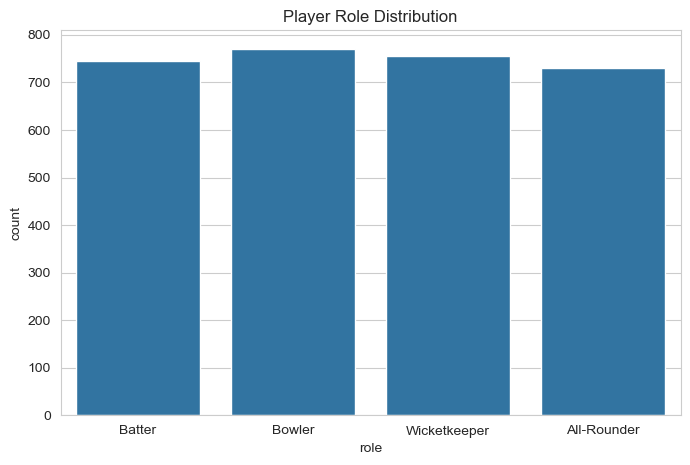

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="role"
)

plt.title("Player Role Distribution")
plt.show()

## Insight: Are roles balanced

## Step 5: Future Potential Distribution

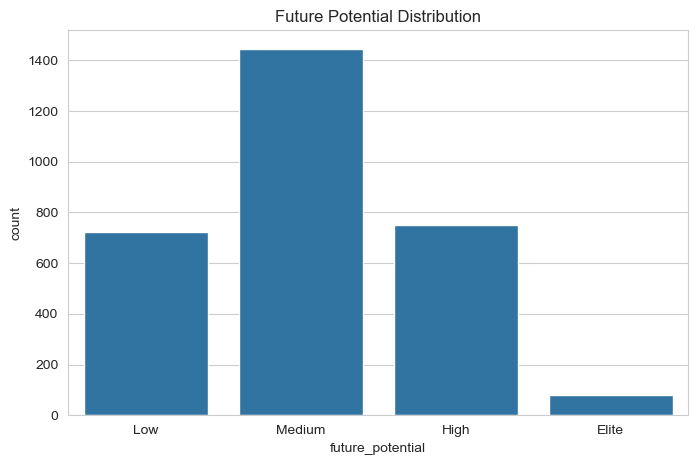

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="future_potential",
    order=["Low","Medium","High","Elite"]
)

plt.title("Future Potential Distribution")
plt.show()

## Insight: Most players are Medium; Elite players are rare.

## Step 6: Talent Score Distribution

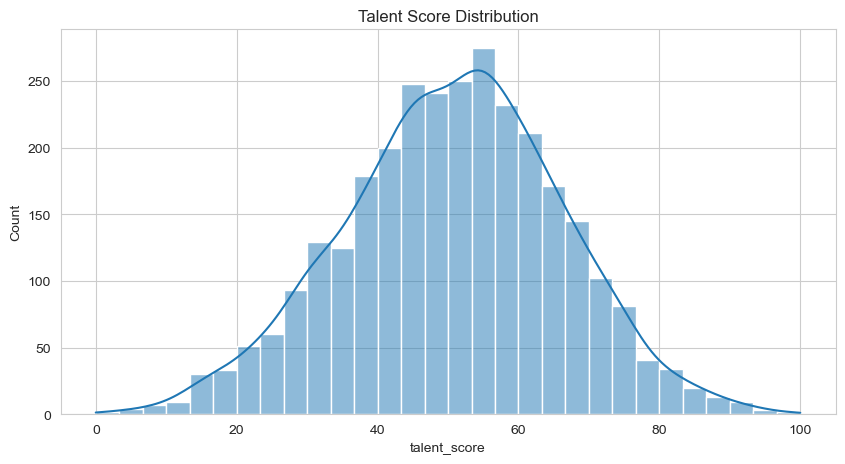

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["talent_score"],
    bins=30,
    kde=True
)

plt.title("Talent Score Distribution")
plt.show()

## Insight: Is the score normally distributed

## Step 7 : Age vs Talent Score

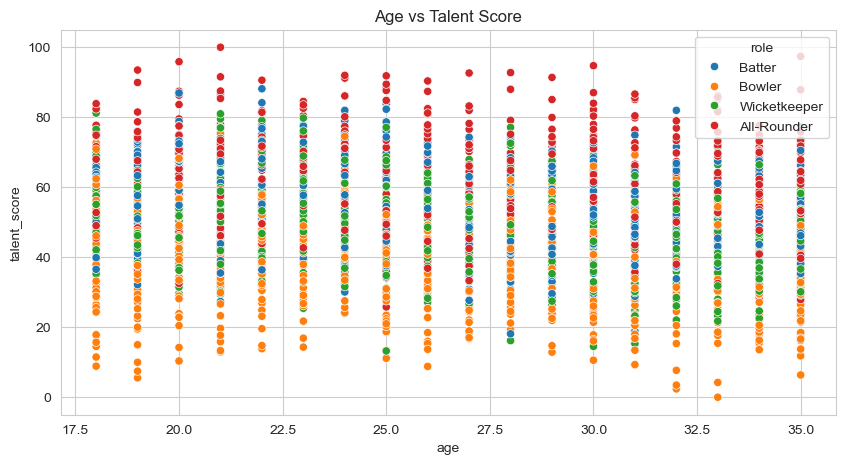

In [8]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="age",
    y="talent_score",
    hue="role"
)

plt.title("Age vs Talent Score")
plt.show()

## Insight: Younger players with high talent may represent future stars.

## Step 8: Runs vs Auction Value

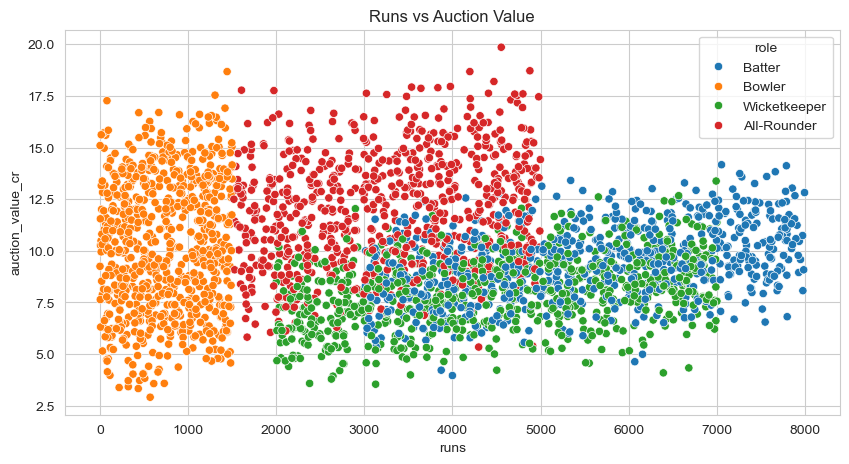

In [9]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="runs",
    y="auction_value_cr",
    hue="role"
)

plt.title("Runs vs Auction Value")
plt.show()

## Step 9: Wickets vs Auction Value

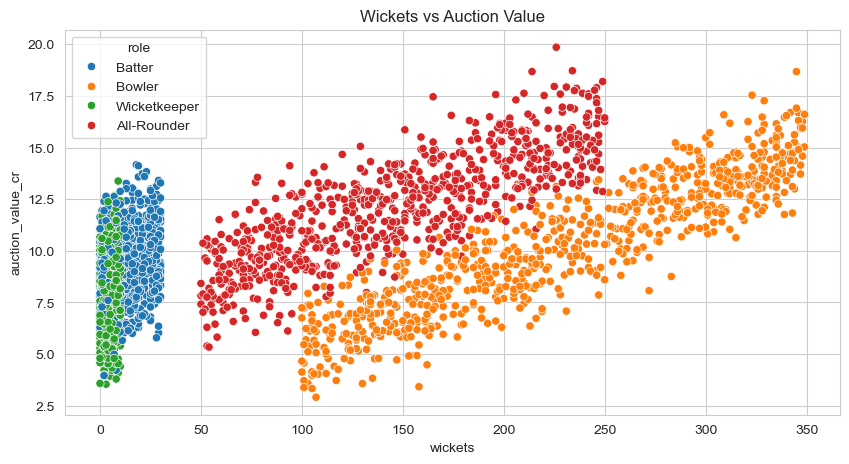

In [10]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="wickets",
    y="auction_value_cr",
    hue="role"
)

plt.title("Wickets vs Auction Value")
plt.show()

## Step 10: Correlation Heatmap

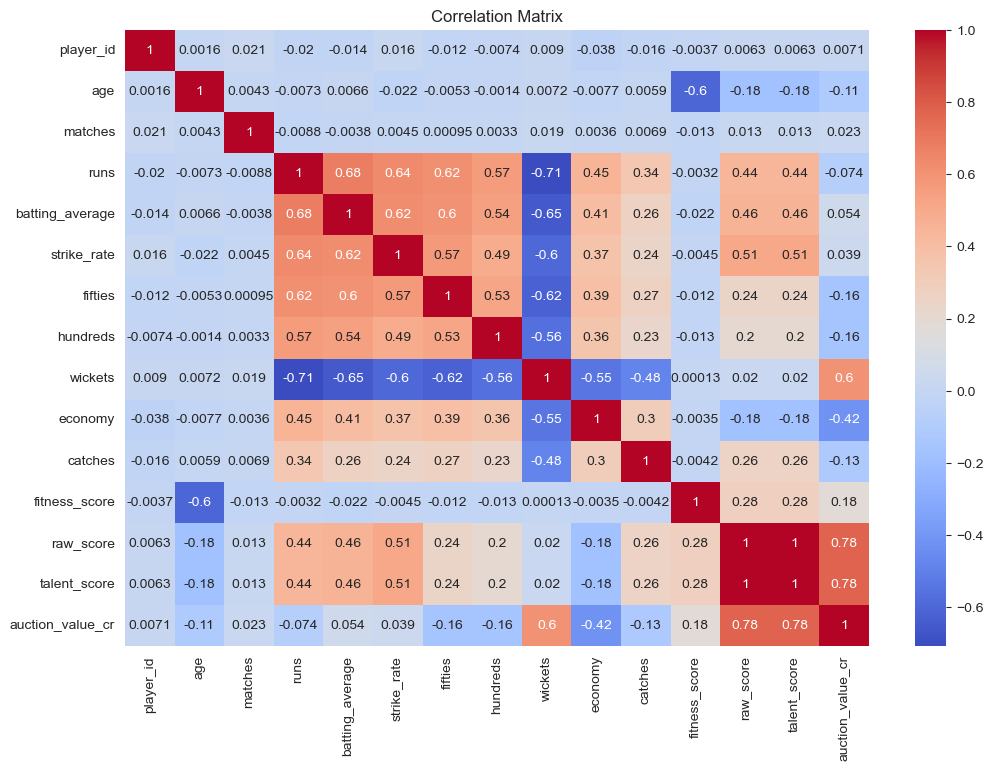

In [11]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# Feature Engineering

In [12]:
df["batting_impact"] = (
    df["batting_average"] * df["strike_rate"]
)

df["bowling_impact"] = (
    df["wickets"] / df["economy"]
)

df["experience_score"] = (
    df["matches"] * df["age"]
)

df["consistency_score"] = (
    df["fifties"] + (2 * df["hundreds"])
)

In [13]:
df.head()

,player_id,age,role,matches,runs,batting_average,strike_rate,fifties,hundreds,wickets,...,catches,fitness_score,raw_score,talent_score,future_potential,auction_value_cr,batting_impact,bowling_impact,experience_score,consistency_score
0,1,21,Batter,199,5253,42.35,129.77,16,18,2,...,14,80,67.5165,31.46,Low,6.18,5495.7595,0.239234,4179,52
1,2,20,Bowler,69,1034,22.04,98.06,5,1,156,...,22,80,66.4690,29.48,Low,7.69,2161.2424,26.896552,1380,7
2,3,23,Wicketkeeper,97,4276,29.66,167.00,26,3,1,...,95,91,79.7900,54.73,Medium,8.39,4953.2200,0.132979,2231,32
3,4,26,Batter,196,6763,51.09,188.12,34,3,17,...,56,88,91.6910,77.28,High,12.93,9611.0508,2.370990,5096,40
4,5,24,Batter,21,4866,58.19,188.97,24,4,12,...,56,85,89.1245,72.42,High,11.72,10996.1643,1.687764,504,32


In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)

df = pd.read_csv("players.csv")

df.head()

,player_id,age,role,matches,runs,batting_average,strike_rate,fifties,hundreds,wickets,economy,catches,fitness_score,raw_score,talent_score,future_potential,auction_value_cr
0,1,21,Batter,199,5253,42.35,129.77,16,18,2,8.36,14,80,67.5165,31.46,Low,6.18
1,2,20,Bowler,69,1034,22.04,98.06,5,1,156,5.80,22,80,66.4690,29.48,Low,7.69
2,3,23,Wicketkeeper,97,4276,29.66,167.00,26,3,1,7.52,95,91,79.7900,54.73,Medium,8.39
3,4,26,Batter,196,6763,51.09,188.12,34,3,17,7.17,56,88,91.6910,77.28,High,12.93
4,5,24,Batter,21,4866,58.19,188.97,24,4,12,7.11,56,85,89.1245,72.42,High,11.72


In [15]:
print("Shape:", df.shape)

df.info()

Shape: (3000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         3000 non-null   int64  
 1   age               3000 non-null   int64  
 2   role              3000 non-null   object 
 3   matches           3000 non-null   int64  
 4   runs              3000 non-null   int64  
 5   batting_average   3000 non-null   float64
 6   strike_rate       3000 non-null   float64
 7   fifties           3000 non-null   int64  
 8   hundreds          3000 non-null   int64  
 9   wickets           3000 non-null   int64  
 10  economy           3000 non-null   float64
 11  catches           3000 non-null   int64  
 12  fitness_score     3000 non-null   int64  
 13  raw_score         3000 non-null   float64
 14  talent_score      3000 non-null   float64
 15  future_potential  3000 non-null   object 
 16  auction_value_cr  3000 n

In [16]:
df.describe()

,player_id,age,matches,runs,batting_average,strike_rate,fifties,hundreds,wickets,economy,catches,fitness_score,raw_score,talent_score,auction_value_cr
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,26.532667,130.154333,3489.569000,36.561803,128.369700,17.813000,5.858000,98.577333,7.001293,57.04700,83.469667,77.658851,50.685823,9.897973
std,866.169729,5.169317,69.912672,2137.236271,13.322923,28.375462,13.446994,5.427491,105.224548,1.496369,35.29457,9.662515,8.172648,15.489983,2.823038
min,1.000000,18.000000,10.000000,1.000000,10.000000,70.080000,0.000000,0.000000,0.000000,4.000000,5.00000,60.000000,50.916500,0.000000,2.910000
25%,750.750000,22.000000,69.000000,1463.250000,26.800000,106.582500,5.000000,1.000000,7.000000,6.057500,29.00000,77.000000,72.231500,40.395000,7.847500
50%,1500.500000,27.000000,129.000000,3547.500000,37.615000,128.035000,16.000000,5.000000,50.000000,7.015000,50.00000,84.000000,78.012500,51.360000,9.520000
75%,2250.250000,31.000000,191.000000,5045.000000,46.480000,150.775000,28.000000,9.250000,179.000000,7.970000,78.00000,91.000000,83.171250,61.132500,11.762500
max,3000.000000,35.000000,250.000000,7994.000000,64.870000,189.970000,50.000000,20.000000,349.000000,10.000000,150.00000,100.000000,103.677500,100.000000,19.860000


In [17]:
df.isnull().sum()

player_id           0
age                 0
role                0
matches             0
runs                0
batting_average     0
strike_rate         0
fifties             0
hundreds            0
wickets             0
economy             0
catches             0
fitness_score       0
raw_score           0
talent_score        0
future_potential    0
auction_value_cr    0
dtype: int64

## Insight 

- Dataset contains 3000 player records.
- No missing values found.
- Age ranges from 18 to 35 years.
- Dataset is clean and ready for analysis.

## Age Distribution

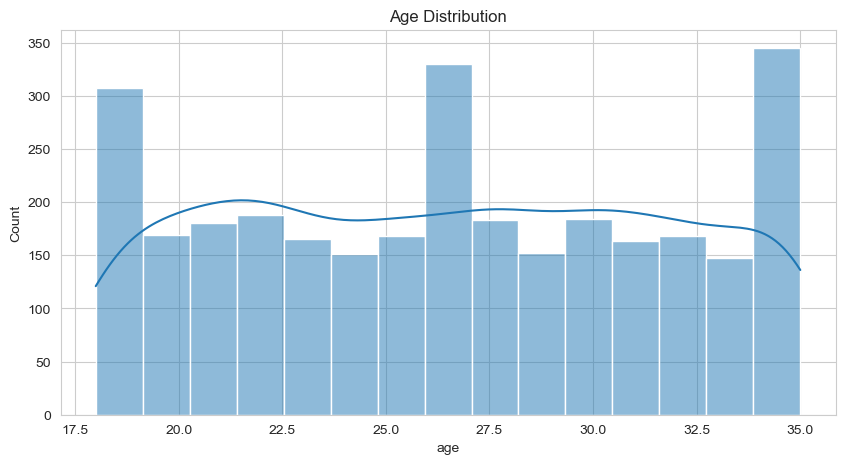

In [18]:
sns.histplot(
    df["age"],
    bins=15,
    kde=True
)

plt.title("Age Distribution")
plt.show()

## Talrnt Score Distribution 

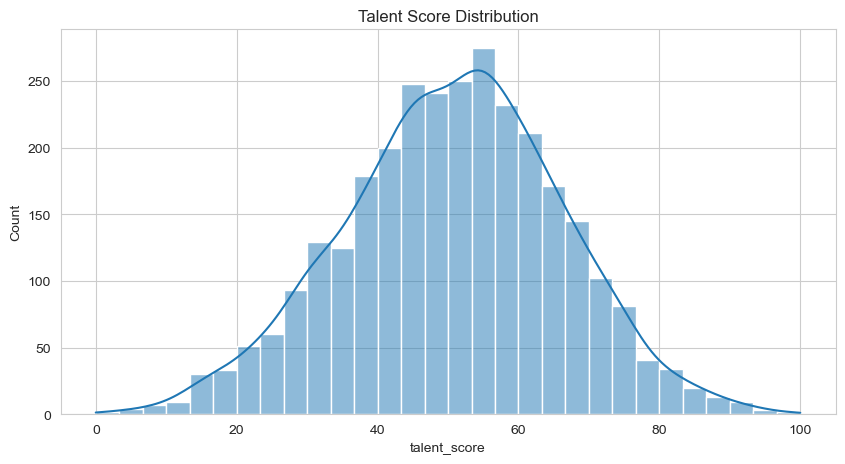

In [19]:
sns.histplot(
    df["talent_score"],
    bins=30,
    kde=True
)

plt.title("Talent Score Distribution")
plt.show()

## Insight : Most talent scores lie in the medium range, indicating a healthy spread of player quality.

## Auction value distribution

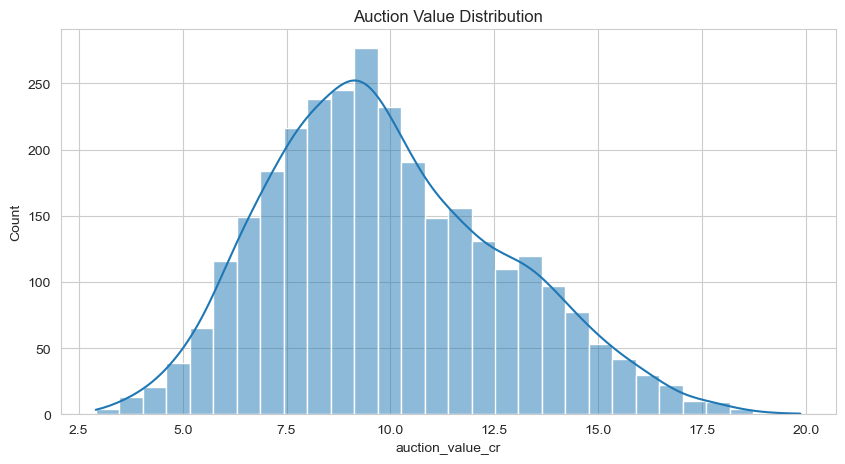

In [21]:
sns.histplot(
    df["auction_value_cr"],
    bins=30,
    kde=True
)

plt.title("Auction Value Distribution")
plt.show()

## Role VS TAlent Score

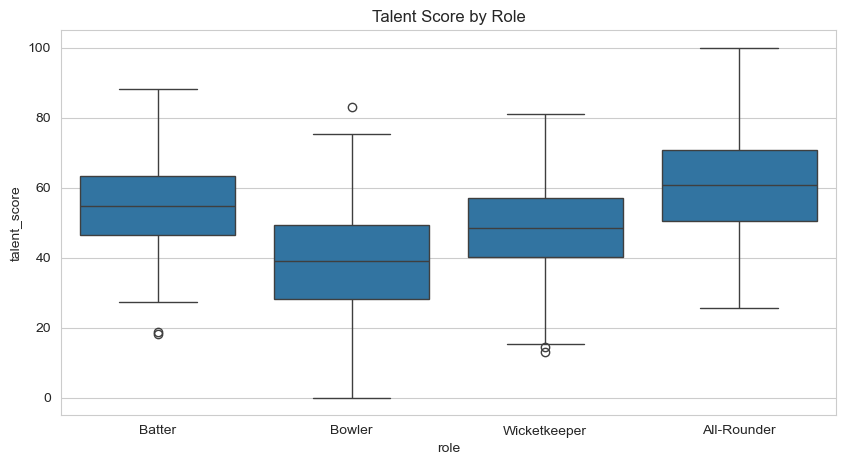

In [22]:
sns.boxplot(
    data=df,
    x="role",
    y="talent_score"
)

plt.title("Talent Score by Role")
plt.show()

# Compare which role tends to achieve higher talent scores.

## Role VS Auction Value

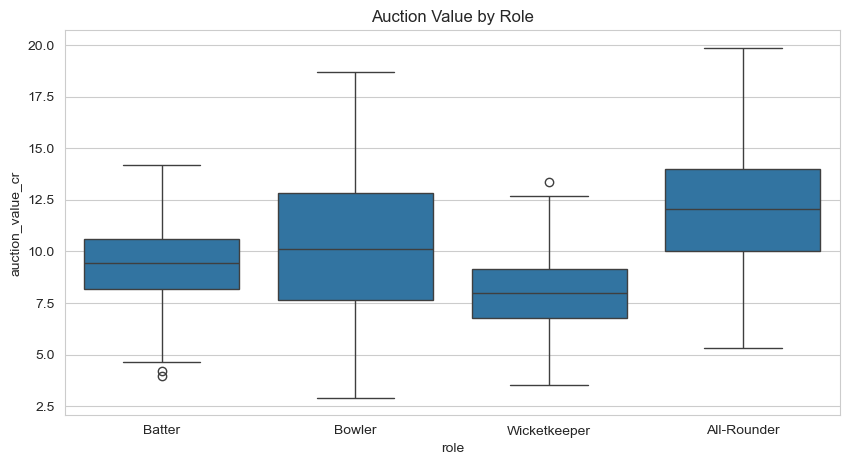

In [23]:
sns.boxplot(
    data=df,
    x="role",
    y="auction_value_cr"
)

plt.title("Auction Value by Role")
plt.show()

## Insights : Identify which player category commands higher market value.

## Wickets vs Auction value

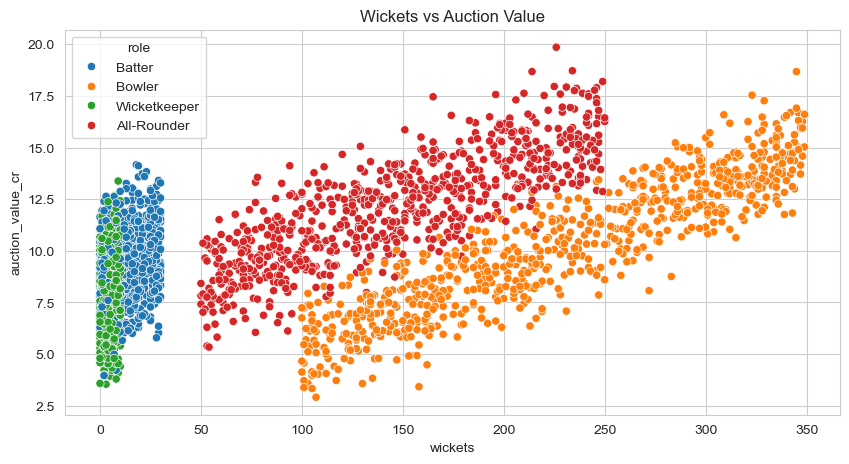

In [24]:
sns.scatterplot(
    data=df,
    x="wickets",
    y="auction_value_cr",
    hue="role"
)

plt.title("Wickets vs Auction Value")
plt.show()

## How much does bowling performance affect market value?

## Top 10 players by talent Score

In [25]:
top_players = df.nlargest(
    10,
    "talent_score"
)

top_players[
    ["player_id","role","talent_score"]
]

,player_id,role,talent_score
1055,1056,All-Rounder,100.00
2989,2990,All-Rounder,97.39
2258,2259,All-Rounder,95.86
2982,2983,All-Rounder,94.73
2488,2489,All-Rounder,93.48
2731,2732,All-Rounder,92.75
1247,1248,All-Rounder,92.63
2674,2675,All-Rounder,91.97
2099,2100,All-Rounder,91.83
2036,2037,All-Rounder,91.54


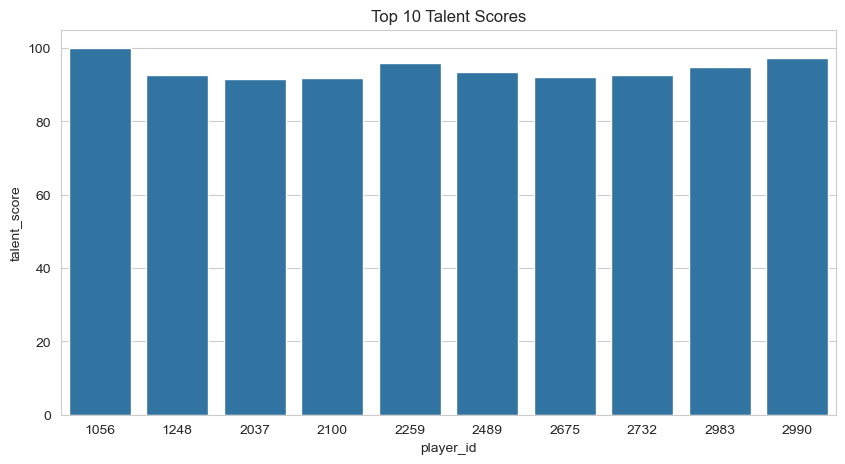

In [26]:
sns.barplot(
    data=top_players,
    x="player_id",
    y="talent_score"
)

plt.title("Top 10 Talent Scores")
plt.show()

## Correlation Analysis

In [27]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

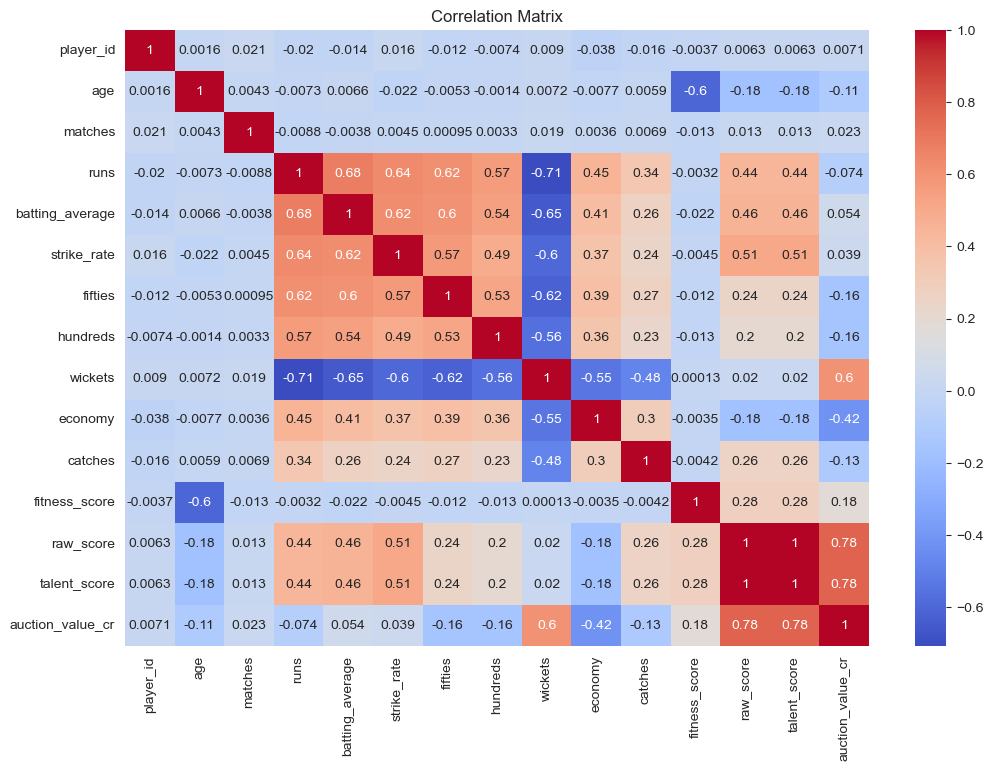

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [33]:
import pandas as pd

df = pd.read_csv("players.csv")

## Feature 1 : Batting Impact

In [43]:
df["batting_impact"] = (
    df["batting_average"] *
    df["strike_rate"]
)

## Feature 2 :  Bowling Impact

In [44]:
df["bowling_impact"] = (
    df["wickets"] /
    df["economy"]
)

## Feature 3 : Experience Score

In [45]:
df["experience_score"] = (
    df["matches"] *
    df["age"]
)

## Feature 4 : Consistency Score

In [46]:
df["consistency_score"] = (
    df["fifties"] +
    (2 * df["hundreds"])
)

In [38]:
print(df.shape)
print(df.columns)

(3000, 21)
Index(['player_id', 'age', 'role', 'matches', 'runs', 'batting_average',
       'strike_rate', 'fifties', 'hundreds', 'wickets', 'economy', 'catches',
       'fitness_score', 'raw_score', 'talent_score', 'future_potential',
       'auction_value_cr', 'batting_impact', 'bowling_impact',
       'experience_score', 'consistency_score'],
      dtype='object')


In [47]:
print(df.columns)

Index(['player_id', 'age', 'role', 'matches', 'runs', 'batting_average',
       'strike_rate', 'fifties', 'hundreds', 'wickets', 'economy', 'catches',
       'fitness_score', 'raw_score', 'talent_score', 'future_potential',
       'auction_value_cr', 'batting_impact', 'bowling_impact',
       'experience_score', 'consistency_score'],
      dtype='object')


# Key Findings

# Key Findings

1. Player roles are evenly distributed.
2. Most players belong to Medium future potential.
3. Talent Score strongly influences auction value.
4. Batting and bowling statistics significantly affect player valuation.
5. Elite players are rare, making them valuable scouting targets.
6. Younger high-scoring players represent strong future prospects.

# Save CSV file as players_featured.csv

In [49]:
df.to_csv(
    "players_featured.csv",
    index=False
)

print("players_featured.csv saved successfully")

players_featured.csv saved successfully
